In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/Users/akosbenjamindoborhegyi/ITU/Second Year/3rd Semester/Machine Learning/Project/Machine-Learning-Tryg-Project/Data/claims_train_with_freq_filtered.csv')

# --- 1. Feature Selection and Scaling ---
# Use the list of features you provided
features_to_scale = df[['ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus']]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_to_scale)

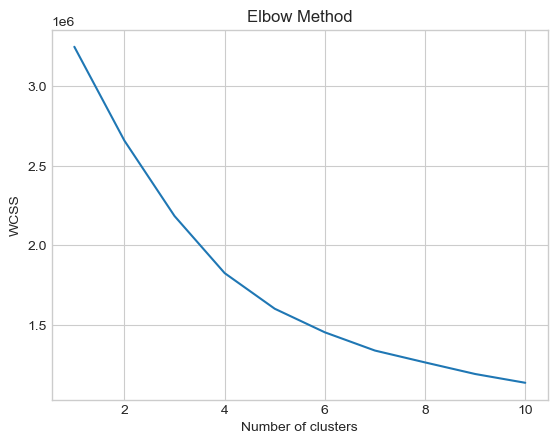

In [11]:
# --- Elbow Method ---
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

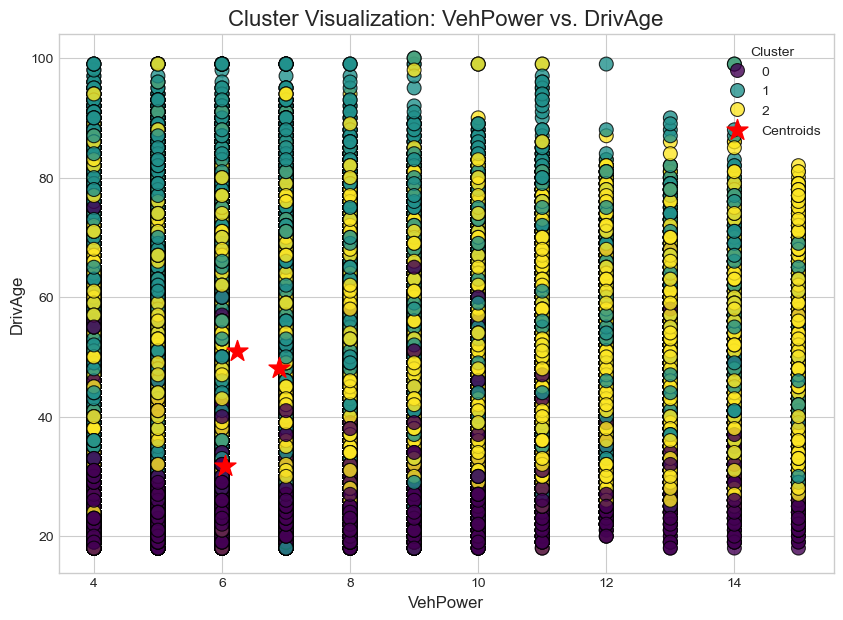

In [ ]:
# --- 2. K-Means Clustering ---
# We perform clustering on the full 6-dimensional data
# We'll assume an optimal number of clusters is 3 for this example.
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels to a new DataFrame for plotting and analysis
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels



In [ ]:
# --- 3. Create the Scatter Plot ---

# !!! IMPORTANT: CHOOSE WHICH TWO FEATURES TO PLOT !!!
# You can change these variables to any two column names from your feature list.
x_axis_feature = 'VehPower'
y_axis_feature = 'DrivAge'

# Setup the plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 7))

# Create a scatter plot of the data points, colored by their cluster
sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue='Cluster', 
                data=df_clustered, palette='viridis', s=100, alpha=0.8, edgecolor='k')

# --- Plotting the Centroids ---
# Get the cluster centers from the KMeans model
# These centers are in the scaled 6-dimensional space
scaled_centers = kmeans.cluster_centers_

# We need to transform them back to the original data space
centers = scaler.inverse_transform(scaled_centers)

# Get the column indices for the features we chose to plot
x_axis_index = features_to_scale.columns.get_loc(x_axis_feature)
y_axis_index = features_to_scale.columns.get_loc(y_axis_feature)

# Plot the cluster centers using the correct columns
plt.scatter(centers[:, x_axis_index], centers[:, y_axis_index], c='red', s=250, marker='*', label='Centroids')

# Add titles and labels for clarity
plt.title(f'Cluster Visualization: {x_axis_feature} vs. {y_axis_feature}', fontsize=16)
plt.xlabel(x_axis_feature, fontsize=12)
plt.ylabel(y_axis_feature, fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()